# Project name: Country-Category Market Segmentation for Strategic Targeting

## 📝 Project info:

#### 🏭 Industry  
- E-commerce & Marketing 

#### 🌐 Domain  
- Lifestyle & Consumer Themes  

## 📂 Dataset Information

#### 🔎 Sources
- **GDELT GKG** (Global Knowledge Graph)  
- **Google Trends**  
- **World Bank Open Data (WDI)**
- **Holidays(Python Library)**
#### All the datasets are **open source** and publicly available.  
- ✅ No privacy, licensing, or access restrictions  
- ✅ Safe for research and personal use 

#### Problem Name: Country-Category Market Segmentation for Strategic Targeting

#### ML Task: Clustering

#### Problem Statement:
With 14 countries and 3 categories, not all country-category markets behave the same. Some are high-interest, low-media markets (untapped demand); others are high-hype, low-interest markets (over-covered). Clustering groups similar markets together so brands and agencies can apply tailored strategies to each segment rather than treating all markets uniformly.

#### Target (y): (Not applicable — unsupervised)
The model discovers cluster labels for each country-category combination. The output is a market typology.

Feature Engineering:

Aggregate to country-category level: reduce the 8,022 rows to 42 rows (14 × 3), each representing one market's behavioral fingerprint
Trend slope: fit a simple OLS regression on Search_Interest vs. Week_Start per market; the slope is a "growth trajectory" feature
Interest volatility: std dev of Search_Interest per group
Normalize all features (StandardScaler) before clustering

#### Why This Problem:
EDA confirmed that demand and media are largely decoupled (r = -0.094). This means markets genuinely differ in their demand-media dynamics — exactly the variation clustering needs. The 42-market fingerprint approach creates a compact, interpretable dataset purpose-built for clustering.

#### Expected ML Output:
3–6 cluster labels with business-interpretable profiles, e.g.:

"Underserved Demand" — high interest, low media
"Overhyped" — high media, low interest
"Established" — high interest + high media, positive sentiment
"Emerging" — rising trend slope, lower absolute interest

Suggested Algorithms:

K-Means (k=3–6, elbow + silhouette selection) — simple, interpretable
Hierarchical Clustering (Ward linkage) — produces a dendrogram for visual storytelling
DBSCAN — detects outlier markets that don't fit any cluster
Gaussian Mixture Models — soft cluster assignments with probability

#### Evaluation Metrics:

Silhouette Score (intra vs. inter-cluster distance)
Davies-Bouldin Index
Business validation: do the clusters make geographic/economic sense?
Visualize with PCA/UMAP (2D) for interpretability


### 💻 Code Work:

In [176]:
import pandas as pd 
import numpy as np
import joblib
import sklearn
import mysql.connector
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import davies_bouldin_score, silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
warnings.filterwarnings('ignore')

### 📤 1. Data Loading (Loading Datafrom Database tables into pandas dataframe df)

In [177]:
# connecting to the MySQL database
connection = mysql.connector.connect(
    host="localhost",
    user="root",
    password="!@Mstrong@1234",
    database="GDELTTrends"
)

In [178]:
# initailizing the cursor
cursor = connection.cursor()
# getting table names from the database
cursor.execute("SHOW TABLES")
# fetching the table names
tables = cursor.fetchall()
print("Tables in GDELTTrends:")
for table in cursor.fetchall():
    print(table[0])

Tables in GDELTTrends:


In [179]:
df = pd.read_sql("SELECT * FROM final_master_dataset;", connection)

In [180]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8022 entries, 0 to 8021
Data columns (total 24 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Week_Start               8022 non-null   datetime64[ns]
 1   Country_Code             8022 non-null   object        
 2   Country_Name             8022 non-null   object        
 3   Category                 8022 non-null   object        
 4   Search_Interest          8022 non-null   float64       
 5   Search_Velocity          8022 non-null   float64       
 6   Search_Acceleration      8022 non-null   float64       
 7   Media_Volume             7725 non-null   float64       
 8   tone_net_sentiment       7725 non-null   float64       
 9   tone_positive_score      7725 non-null   float64       
 10  tone_negative_score      7725 non-null   float64       
 11  tone_polarity            7725 non-null   float64       
 12  tone_activity_density    7725 non-

### 👩🏻‍💻 1. Modeling

#### 🛠️ 1.1 Pre-Requisites
- Entire data will be considered as X as there is no target column but I cannot use the features in dataset as they are for this clusttering problem they need to be modified

### Input Features (X)

| Feature                     | Aggregation Method                                | Role                                               |
|-----------------------------|---------------------------------------------------|----------------------------------------------------|
| `Mean_Search_Interest`      | mean(Search_Interest)                             | Baseline consumer demand level                     |
| `Mean_Media_Volume`         | mean(Media_Volume)                                | Media coverage intensity                           |
| `Mean_Demand_to_Hype_Ratio` | mean(Demand_to_Hype_Ratio)                        | Demand-to-coverage efficiency (underserved vs. overhyped) |
| `Search_Interest_Trend_Slope` | OLS Regression Slope (Search_Interest vs Week_Start) | Growth trajectory (rising vs. declining market)    |
| `Mean_Net_Sentiment`        | mean(tone_net_sentiment)                          | Overall public sentiment tone                      |
| `Mean_GDP_Per_Capita`       | mean(GDP_Per_Capita)                              | Economic maturity and purchasing power             |


#### Before proceding to convert all the feature to model needs, lets handle null values and outliers

#### 🔄 1.1.1 Missing Values & Outliers Handling

In [181]:
df.isnull().sum()

Week_Start                   0
Country_Code                 0
Country_Name                 0
Category                     0
Search_Interest              0
Search_Velocity              0
Search_Acceleration          0
Media_Volume               297
tone_net_sentiment         297
tone_positive_score        297
tone_negative_score        297
tone_polarity              297
tone_activity_density      297
tone_self_group_density    297
Source_Diversity           297
Demand_to_Hype_Ratio       297
Media_Volume_per_Source    297
Interest_per_Source        297
Year                         0
Inflation_Rate               0
Internet_Penetration         0
GDP_Per_Capita               0
is_holiday                   0
holiday_count                0
dtype: int64

In [182]:
# null Values in all the columns can be replaced with 0, since they are real world values is 0, it is a valid value for them.
null_cols = df.columns[df.isnull().any()]
for col in null_cols:
    df[col]=df[col].fillna(0)

In [183]:
df.columns[df.isnull().any()]

Index([], dtype='object')

##### Missing values are handled, no null values in x columns
##### for this real world dataset, there is no need for handling outliers, based on model output I'll look into this aspect

#### **Feature Selection (Mandatory)**
- As mentioned above only those columns needed will be kept

In [184]:
cols = [
    'Country_Name','Category','Search_Interest',
    'Media_Volume','tone_net_sentiment',
    'Demand_to_Hype_Ratio','Source_Diversity'
]

df1 = df[cols].copy()

**Feature Generation**

In [185]:
# Initialize the 42-market base DataFrame (14 countries x 3 categories)
X = df[["Country_Name", "Category"]].drop_duplicates().reset_index(drop=True)

### Mean Search_Interest per country-category

In [186]:
mean_search = (df.groupby(["Country_Name", "Category"])["Search_Interest"].mean().reset_index(name="Mean_Search_Interest"))
X = pd.merge(X, mean_search, on=["Country_Name", "Category"])

### Mean_Media_Volume

In [187]:
Mean_Media_Volume = (
    df.groupby(["Country_Name", "Category"])["Media_Volume"]
    .mean()
    .reset_index(name="Mean_Media_Volume")
)
X = pd.merge(X, Mean_Media_Volume, on=["Country_Name", "Category"])

### Mean_Demand_to_Hype_Ratio

In [188]:
Mean_Demand_to_Hype_Ratio = (
    df.groupby(["Country_Name", "Category"])["Demand_to_Hype_Ratio"]
    .mean()
    .reset_index(name="Mean_Demand_to_Hype_Ratio")
)
X = pd.merge(X, Mean_Demand_to_Hype_Ratio, on=["Country_Name", "Category"])

### Search_Interest_Trend_Slope (OLS Regression Slope)

In [189]:
def calculate_slope(group):
    group = group.sort_values("Week_Start")
    x = (group["Week_Start"] - group["Week_Start"].min()).dt.days // 7 + 1
    y = group["Search_Interest"]

    x_mean, y_mean = x.mean(), y.mean()
    denominator = np.sum((x - x_mean) ** 2)

    return (
        np.sum((x - x_mean) * (y - y_mean)) / denominator
        if denominator != 0
        else 0
    )

Search_Interest_Trend_Slope = (
    df.groupby(["Country_Name", "Category"])
    .apply(calculate_slope)
    .reset_index(name="Search_Interest_Trend_Slope")
)
X = pd.merge(X, Search_Interest_Trend_Slope, on=["Country_Name", "Category"])

### Mean_Net_Sentiment

In [190]:
mean_net_sentiment = (
    df.groupby(["Country_Name", "Category"])["tone_net_sentiment"]
    .mean()
    .reset_index(name="Mean_Net_Sentiment")
)
X = pd.merge(X, mean_net_sentiment, on=["Country_Name", "Category"])

### Mean_GDP_Per_Capita

In [191]:
mean_gdp_per_capita = (
    df.groupby(["Country_Name", "Category"])["GDP_Per_Capita"]
    .mean()
    .reset_index(name="Mean_GDP_Per_Capita")
)
X = pd.merge(X, mean_gdp_per_capita, on=["Country_Name", "Category"])

In [192]:
X.shape

(42, 8)

In [193]:
X.head()

,Country_Name,Category,Mean_Search_Interest,Mean_Media_Volume,Mean_Demand_to_Hype_Ratio,Search_Interest_Trend_Slope,Mean_Net_Sentiment,Mean_GDP_Per_Capita
0,United_Arab_Emirates,Fashion_Beauty,70.239424,196.303665,0.396829,0.046284,1.502719,50156.182984
1,United_Arab_Emirates,Fitness_Wearables,76.238586,52.727749,2.003892,0.105490,1.904257,50156.182984
2,United_Arab_Emirates,Nutrition_Diets,67.783560,932.062827,0.082321,-0.007249,-0.116729,50156.182984
3,Australia,Fashion_Beauty,64.832461,436.638743,0.161245,0.050203,-0.034361,64734.412356
4,Australia,Fitness_Wearables,79.414974,48.052356,1.908886,0.066122,0.842949,64734.412356


**Encoding **

In [194]:
# Set metadata columns as DataFrame Index to preserve labels without One-Hot Encoding
X_labeled = X.set_index(["Country_Name", "Category"])

# Define numerical feature columns to feed into the scaler & K-Means
numerical_features = [
    "Mean_Search_Interest",
    "Mean_Media_Volume",
    "Mean_Demand_to_Hype_Ratio",
    "Search_Interest_Trend_Slope",
    "Mean_Net_Sentiment",
    "Mean_GDP_Per_Capita",
]

# Extract numerical array for modeling
X_numerical = X_labeled[numerical_features]


In [195]:
X_numerical

Mean_Search_Interest  \
Country_Name         Category                                  
United_Arab_Emirates Fashion_Beauty                70.239424   
                     Fitness_Wearables             76.238586   
                     Nutrition_Diets               67.783560   
Australia            Fashion_Beauty                64.832461   
                     Fitness_Wearables             79.414974   
                     Nutrition_Diets               77.638272   
Brazil               Fashion_Beauty                56.511152   
                     Fitness_Wearables             64.779005   
                     Nutrition_Diets               36.071885   
Canada               Fashion_Beauty                65.666440   
                     Fitness_Wearables             72.589738   
                     Nutrition_Diets               72.403455   
China                Fashion_Beauty                17.685183   
                     Fitness_Wearables             33.393298   
                     Nutrition_Diets               11.670733   
France               Fashion_Beauty                33.807749   
                     Fitness_Wearables             63.110942   
                     Nutrition_Diets               39.899948   
United_Kingdom       Fashion_Beauty                53.347225   
                     Fitness_Wearables             73.477958   
                     Nutrition_Diets               74.295916   
India                Fashion_Beauty                54.566963   
                     Fitness_Wearables             75.252251   
                     Nutrition_Diets               78.869843   
Kenya                Fashion_Beauty                78.393927   
                     Fitness_Wearables             74.590105   
                     Nutrition_Diets               71.082618   
Mexico               Fashion_Beauty                62.194084   
                     Fitness_Wearables             70.954346   
                     Nutrition_Diets               35.670105   
Nigeria              Fashion_Beauty                77.325707   
                     Fitness_Wearables             76.567749   
                     Nutrition_Diets               75.640890   
Singapore            Fashion_Beauty                52.646021   
                     Fitness_Wearables             68.945497   
                     Nutrition_Diets               56.797696   
United_States        Fashion_Beauty                47.433141   
                     Fitness_Wearables             59.576178   
                     Nutrition_Diets               58.314869   
South_Africa         Fashion_Beauty                75.393194   
                     Fitness_Wearables             75.305707   
                     Nutrition_Diets               66.400419   

                                        Mean_Media_Volume  \
Country_Name         Category                               
United_Arab_Emirates Fashion_Beauty            196.303665   
                     Fitness_Wearables          52.727749   
                     Nutrition_Diets           932.062827   
Australia            Fashion_Beauty            436.638743   
                     Fitness_Wearables          48.052356   
                     Nutrition_Diets          2432.104712   
Brazil               Fashion_Beauty           1039.314136   
                     Fitness_Wearables          70.874346   
                     Nutrition_Diets          7233.612565   
Canada               Fashion_Beauty            976.178010   
                     Fitness_Wearables         116.534031   
                     Nutrition_Diets          9218.198953   
China                Fashion_Beauty              1.968586   
                     Fitness_Wearables           0.691099   
                     Nutrition_Diets            14.314136   
France               Fashion_Beauty           4003.664921   
                     Fitness_Wearables         435.638743   
                     Nutrition_Diets         13133.120419   
Uni

### **Scaling**

In [196]:
# Standardize numerical features (Mean=0, Std=1)
scaler = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X_numerical),
    columns=numerical_features,
    index=X_labeled.index,
)

display(X_scaled)

Mean_Search_Interest  \
Country_Name         Category                                  
United_Arab_Emirates Fashion_Beauty                 0.498408   
                     Fitness_Wearables              0.853884   
                     Nutrition_Diets                0.352888   
Australia            Fashion_Beauty                 0.178023   
                     Fitness_Wearables              1.042099   
                     Nutrition_Diets                0.936821   
Brazil               Fashion_Beauty                -0.315050   
                     Fitness_Wearables              0.174855   
                     Nutrition_Diets               -1.526164   
Canada               Fashion_Beauty                 0.227439   
                     Fitness_Wearables              0.637674   
                     Nutrition_Diets                0.626636   
China                Fashion_Beauty                -2.615654   
                     Fitness_Wearables             -1.684882   
                     Nutrition_Diets               -2.972036   
France               Fashion_Beauty                -1.660324   
                     Fitness_Wearables              0.076015   
                     Nutrition_Diets               -1.299335   
United_Kingdom       Fashion_Beauty                -0.502527   
                     Fitness_Wearables              0.690305   
                     Nutrition_Diets                0.738773   
India                Fashion_Beauty                -0.430252   
                     Fitness_Wearables              0.795439   
                     Nutrition_Diets                1.009797   
Kenya                Fashion_Beauty                 0.981597   
                     Fitness_Wearables              0.756204   
                     Nutrition_Diets                0.548371   
Mexico               Fashion_Beauty                 0.021687   
                     Fitness_Wearables              0.540770   
                     Nutrition_Diets               -1.549971   
Nigeria              Fashion_Beauty                 0.918301   
                     Fitness_Wearables              0.873388   
                     Nutrition_Diets                0.818468   
Singapore            Fashion_Beauty                -0.544076   
                     Fitness_Wearables              0.421737   
                     Nutrition_Diets               -0.298071   
United_States        Fashion_Beauty                -0.852961   
                     Fitness_Wearables             -0.133435   
                     Nutrition_Diets               -0.208172   
South_Africa         Fashion_Beauty                 0.803791   
                     Fitness_Wearables              0.798607   
                     Nutrition_Diets                0.270931   

                                        Mean_Media_Volume  \
Country_Name         Category                               
United_Arab_Emirates Fashion_Beauty             -0.260224   
                     Fitness_Wearables          -0.268396   
                     Nutrition_Diets            -0.218346   
Australia            Fashion_Beauty             -0.246545   
                     Fitness_Wearables          -0.268663   
                     Nutrition_Diets            -0.132967   
Brazil               Fashion_Beauty             -0.212242   
                     Fitness_Wearables          -0.267364   
                     Nutrition_Diets             0.140327   
Canada               Fashion_Beauty             -0.215835   
                     Fitness_Wearables          -0.264765   
                     Nutrition_Diets             0.253286   
China                Fashion_Beauty             -0.271286   
                     Fitness_Wearables          -0.271358   
                     Nutrition_Diets            -0.270583   
France               Fashion_Beauty             -0.043516   
                     Fitness_Wearables          -0.246602   
                     Nutrition_Diets             0.476116   
Uni

#### 🤖 1.2 Model + Define, Train & Study

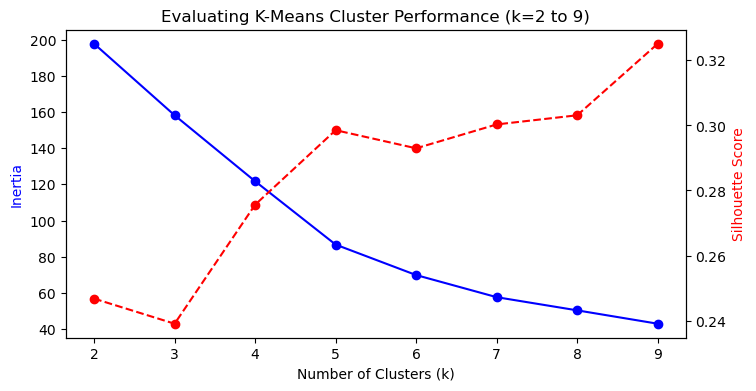

In [197]:

# 1. Optimal K Selection (Elbow Method & Silhouette Scores)

inertia = []
silhouette_scores = []
k_range = range(2, 10)

for k in k_range:
    kmeans_test = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans_test.fit_predict(X_scaled)

    inertia.append(kmeans_test.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, cluster_labels))

# Plot Elbow Curve and Silhouette Scores
fig, ax1 = plt.subplots(figsize=(8, 4))

ax1.plot(k_range, inertia, "bo-", label="Inertia (Elbow)")
ax1.set_xlabel("Number of Clusters (k)")
ax1.set_ylabel("Inertia", color="b")

ax2 = ax1.twinx()
ax2.plot(k_range, silhouette_scores, "ro--", label="Silhouette Score")
ax2.set_ylabel("Silhouette Score", color="r")

plt.title("Evaluating K-Means Cluster Performance (k=2 to 9)")
plt.show()



In [198]:
# 2. Define, Fit & Predict (Selecting optimal k = 5)

# Instantiate K-Means model with optimal cluster count
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)

# Fit model & assign cluster group numbers (0, 1, 2, 3,4) to each row
X_labeled["Cluster_Label"] = kmeans.fit_predict(X_scaled)
X_scaled["Cluster_Label"] = X_labeled["Cluster_Label"]

# 3. Model Study & Evaluation

final_silhouette = silhouette_score(
    X_scaled.drop(columns=["Cluster_Label"]), X_labeled["Cluster_Label"]
)
final_db_index = davies_bouldin_score(
    X_scaled.drop(columns=["Cluster_Label"]), X_labeled["Cluster_Label"]
)

print(f"Model Training Complete!")
print(f"Silhouette Score: {final_silhouette:.3f} (Higher is better, max 1.0)")
print(
    f"Davies-Bouldin Index: {final_db_index:.3f} (Lower is better, min 0.0)\n"
)

# Display sample of market rows with assigned group numbers
print("Sample Market Group Assignments:")
print(X_labeled[["Mean_Search_Interest", "Cluster_Label"]].head(10))

Model Training Complete!
Silhouette Score: 0.299 (Higher is better, max 1.0)
Davies-Bouldin Index: 0.896 (Lower is better, min 0.0)

Sample Market Group Assignments:
                                        Mean_Search_Interest  Cluster_Label
Country_Name         Category                                              
United_Arab_Emirates Fashion_Beauty                70.239424              2
                     Fitness_Wearables             76.238586              2
                     Nutrition_Diets               67.783560              2
Australia            Fashion_Beauty                64.832461              2
                     Fitness_Wearables             79.414974              2
                     Nutrition_Diets               77.638272              2
Brazil               Fashion_Beauty                56.511152              0
                     Fitness_Wearables             64.779005              0
                     Nutrition_Diets               36.071885              

In [199]:
X_labeled.columns

Index(['Mean_Search_Interest', 'Mean_Media_Volume',
       'Mean_Demand_to_Hype_Ratio', 'Search_Interest_Trend_Slope',
       'Mean_Net_Sentiment', 'Mean_GDP_Per_Capita', 'Cluster_Label'],
      dtype='object')

#### ✅ 1.3 Adding predictions to Original Data
- Adding above predictions as a column to main data

In [200]:
# 1. Reset MultiIndex on Fingerprint Dataset to extract keys

# Convert Country_Code and Category from Index back to columns
cluster_mapping = X_labeled[["Cluster_Label"]].reset_index()

# ---------------------------------------------------------
# 2. Merge Cluster Labels back into the Main Dataset (8,022 rows)
# ---------------------------------------------------------
# Left join on Country_Code and Category to preserve full timeseries structure
df_final = pd.merge(
    df, cluster_mapping, on=["Country_Name", "Category"], how="left"
)

# ---------------------------------------------------------
# 3. Validation & Sanity Checks
# ---------------------------------------------------------
print(f"Original Raw Dataset Shape: {df.shape}")
print(f"Main Dataset with Clusters Shape: {df_final.shape}")
print(
    f"Missing Cluster Values: {df_final['Cluster_Label'].isna().sum()}"
)  # Should be 0

# Preview sample of main dataset with newly added Cluster_Label column
print("\nSample Rows from Main Dataset with Assigned Group Numbers:")
display(
    df_final[
        [
            "Week_Start",
            "Country_Name",
            "Category",
            "Search_Interest",
            "Media_Volume",
            "Cluster_Label",
        ]
    ].head(10)
)

Original Raw Dataset Shape: (8022, 24)
Main Dataset with Clusters Shape: (8022, 25)
Missing Cluster Values: 0

Sample Rows from Main Dataset with Assigned Group Numbers:


,Week_Start,Country_Name,Category,Search_Interest,Media_Volume,Cluster_Label
0,2023-01-01,United_Arab_Emirates,Fashion_Beauty,67.23,115.0,2
1,2023-01-01,United_Arab_Emirates,Fitness_Wearables,72.78,52.0,2
2,2023-01-01,United_Arab_Emirates,Nutrition_Diets,74.40,845.0,2
3,2023-01-08,United_Arab_Emirates,Fashion_Beauty,65.42,127.0,2
4,2023-01-08,United_Arab_Emirates,Fitness_Wearables,70.28,32.0,2
5,2023-01-08,United_Arab_Emirates,Nutrition_Diets,69.17,1065.0,2
6,2023-01-15,United_Arab_Emirates,Fashion_Beauty,66.51,168.0,2
7,2023-01-15,United_Arab_Emirates,Fitness_Wearables,71.74,30.0,2
8,2023-01-15,United_Arab_Emirates,Nutrition_Diets,73.12,1090.0,2
9,2023-01-22,United_Arab_Emirates,Fashion_Beauty,65.90,151.0,2


#### 📥 1.4 Saving groups & Study
- Save above group number added data to csv/excel
- group wise stats
    - Once group number added to row, then filter rows based on group number

In [201]:
# Save Datasets to CSV 
# Save as individual CSV files
X_labeled.reset_index().to_csv("market_fingerprints_clustered.csv", index=False)
df_final.to_csv("full_timeseries_clustered.csv", index=False)
print("Files successfully saved to CSV!")

Files successfully saved to CSV!


In [202]:
# 2. Compute Group-Wise Statistics (Market Profiles)

# Define the 6 core features to aggregate
core_features = ["Mean_Search_Interest","Mean_Media_Volume","Mean_Demand_to_Hype_Ratio","Search_Interest_Trend_Slope","Mean_Net_Sentiment","Mean_GDP_Per_Capita"]

# Calculate mean and std for each feature grouped by cluster number
group_stats = (X_labeled.groupby("Cluster_Label")[core_features].agg(["mean"]).round(2))
# Append total market count per group
group_stats[("Market_Count", "count")] = X_labeled.groupby("Cluster_Label")["Mean_Search_Interest"].count()
print("\n--- Group-Wise Summary Statistics ---")
display(group_stats)



--- Group-Wise Summary Statistics ---


,Mean_Search_Interest,Mean_Media_Volume,Mean_Demand_to_Hype_Ratio,Search_Interest_Trend_Slope,Mean_Net_Sentiment,Mean_GDP_Per_Capita,Market_Count
,mean,mean,mean,mean,mean,mean,count
Cluster_Label,,,,,,,
0,43.10,2956.53,0.97,0.10,-0.70,17199.27,12
1,58.31,114320.38,0.00,0.06,-1.69,85175.46,1
2,66.06,2125.46,1.02,0.07,-0.05,65178.20,17
3,74.77,1589.72,0.86,-0.05,-0.33,2944.08,9
4,75.12,8.49,11.69,0.03,1.61,19990.40,3


In [203]:
# 3. Filter Rows Based on Group Number

# Filter 42-Market Fingerprints in all Groups
group_0_fingerprints = X_labeled[X_labeled["Cluster_Label"] == 0]
print(
    f"\nTotal Markets in Group 0: {len(group_0_fingerprints)}"
)
display(group_0_fingerprints)

group_1_fingerprints = X_labeled[X_labeled["Cluster_Label"] == 1]
print(
    f"\nTotal Markets in Group 1: {len(group_1_fingerprints)}"
)
display(group_1_fingerprints)

group_2_fingerprints = X_labeled[X_labeled["Cluster_Label"] == 2]
print(
    f"\nTotal Markets in Group 2: {len(group_2_fingerprints)}"
)
display(group_2_fingerprints)

group_3_fingerprints = X_labeled[X_labeled["Cluster_Label"] == 3]
print(
    f"\nTotal Markets in Group 3: {len(group_3_fingerprints)}"
)
display(group_3_fingerprints)

group_4_fingerprints = X_labeled[X_labeled["Cluster_Label"] == 4]
print(
    f"\nTotal Markets in Group 4: {len(group_4_fingerprints)}"
)
display(group_4_fingerprints)


Total Markets in Group 0: 12


Mean_Search_Interest  Mean_Media_Volume  \
Country_Name Category                                                     
Brazil       Fashion_Beauty                56.511152        1039.314136   
             Fitness_Wearables             64.779005          70.874346   
             Nutrition_Diets               36.071885        7233.612565   
China        Fashion_Beauty                17.685183           1.968586   
             Fitness_Wearables             33.393298           0.691099   
             Nutrition_Diets               11.670733          14.314136   
France       Fashion_Beauty                33.807749        4003.664921   
             Nutrition_Diets               39.899948       13133.120419   
India        Fashion_Beauty                54.566963        1912.549738   
Mexico       Fashion_Beauty                62.194084        1527.848168   
             Fitness_Wearables             70.954346          78.617801   
             Nutrition_Diets               35.670105        6461.806283   

                                Mean_Demand_to_Hype_Ratio  \
Country_Name Category                                       
Brazil       Fashion_Beauty                      0.055915   
             Fitness_Wearables                   1.247076   
             Nutrition_Diets                     0.005103   
China        Fashion_Beauty                      3.939899   
             Fitness_Wearables                   3.832434   
             Nutrition_Diets                     1.389486   
France       Fashion_Beauty                      0.008934   
             Nutrition_Diets                     0.003163   
India        Fashion_Beauty                      0.030815   
Mexico       Fashion_Beauty                      0.043591   
             Fitness_Wearables                   1.046229   
             Nutrition_Diets                     0.005664   

                                Search_Interest_Trend_Slope  \
Country_Name Category                                         
Brazil       Fashion_Beauty                        0.095067   
             Fitness_Wearables                     0.094239   
             Nutrition_Diets                       0.098694   
China        Fashion_Beauty                        0.064861   
             Fitness_Wearables                     0.122587   
             Nutrition_Diets                       0.107397   
France       Fashion_Beauty                        0.080552   
             Nutrition_Diets                       0.151221   
India        Fashion_Beauty                        0.027144   
Mexico       Fashion_Beauty                        0.104459   
             Fitness_Wearables                     0.108553   
             Nutrition_Diets                       0.131626   

                                Mean_Net_Sentiment  Mean_GDP_Per_Capita  \
Country_Name Category                                                     
Brazil       Fashion_Beauty               0.061773         10329.152723   
             Fitness_Wearables           -0.420048         10329.152723   
             Nutrition_Diets             -1.564369         10329.152723   
China        Fashion_Beauty              -0.503225         13198.236126   
             Fitness_Wearables            0.265260         13198.236126   
             Nutrition_Diets             -1.211966         13198.236126   
France       Fashion_Beauty               0.001634         45713.782513   
             Nutrition_Diets             -1.401405         45713.782513   
India        Fashion_Beauty              -0.333704          2548.274712   
Mexico       Fashion_Beauty               0.020569         13944.419058   
             Fitness_Wearables           -1.542967         13944.419058   
             Nutrition_Diets             -1.726374         13944.419058   

                                Cluster_Label  
Country_Name Category                          
Brazil       Fashion_Beauty                 0  
             Fitness_Wearables              0  



Total Markets in Group 1: 1


,,Mean_Search_Interest,Mean_Media_Volume,Mean_Demand_to_Hype_Ratio,Search_Interest_Trend_Slope,Mean_Net_Sentiment,Mean_GDP_Per_Capita,Cluster_Label
Country_Name,Category,,,,,,,
United_States,Nutrition_Diets,58.314869,114320.376963,0.00052,0.063328,-1.689992,85175.457696,1



Total Markets in Group 2: 17


Mean_Search_Interest  \
Country_Name         Category                                  
United_Arab_Emirates Fashion_Beauty                70.239424   
                     Fitness_Wearables             76.238586   
                     Nutrition_Diets               67.783560   
Australia            Fashion_Beauty                64.832461   
                     Fitness_Wearables             79.414974   
                     Nutrition_Diets               77.638272   
Canada               Fashion_Beauty                65.666440   
                     Fitness_Wearables             72.589738   
                     Nutrition_Diets               72.403455   
France               Fitness_Wearables             63.110942   
United_Kingdom       Fashion_Beauty                53.347225   
                     Nutrition_Diets               74.295916   
Singapore            Fashion_Beauty                52.646021   
                     Fitness_Wearables             68.945497   
                     Nutrition_Diets               56.797696   
United_States        Fashion_Beauty                47.433141   
                     Fitness_Wearables             59.576178   

                                        Mean_Media_Volume  \
Country_Name         Category                               
United_Arab_Emirates Fashion_Beauty            196.303665   
                     Fitness_Wearables          52.727749   
                     Nutrition_Diets           932.062827   
Australia            Fashion_Beauty            436.638743   
                     Fitness_Wearables          48.052356   
                     Nutrition_Diets          2432.104712   
Canada               Fashion_Beauty            976.178010   
                     Fitness_Wearables         116.534031   
                     Nutrition_Diets          9218.198953   
France               Fitness_Wearables         435.638743   
United_Kingdom       Fashion_Beauty             17.198953   
                     Nutrition_Diets            63.607330   
Singapore            Fashion_Beauty            118.471204   
                     Fitness_Wearables          16.926702   
                     Nutrition_Diets           325.361257   
United_States        Fashion_Beauty          17595.418848   
                     Fitness_Wearables        3151.429319   

                                        Mean_Demand_to_Hype_Ratio  \
Country_Name         Category                                       
United_Arab_Emirates Fashion_Beauty                      0.396829   
                     Fitness_Wearables                   2.003892   
                     Nutrition_Diets                     0.082321   
Australia            Fashion_Beauty                      0.161245   
                     Fitness_Wearables                   1.908886   
                     Nutrition_Diets                     0.032452   
Canada               Fashion_Beauty                      0.071567   
                     Fitness_Wearables                   0.694576   
                     Nutrition_Diets                     0.008294   
France               Fitness_Wearables                   0.156531   
United_Kingdom       Fashion_Beauty                      4.673709   
                     Nutrition_Diets                     1.363780   
Singapore            Fashion_Beauty                      0.632497   
                     Fitness_Wearables                   4.880771   
                     Nutrition_Diets                     0.179672   
United_States        Fashion_Beauty                      0.002729   
                     Fitness_Wearables                   0.024370   

                                        Search_Interest_Trend_Slope  \
Country_Name         Category                                         
United_Arab_Emirates Fashion_Beauty                        0.046284   
                     Fitness_Wearables                     0.105490   
                     Nutrition_Diets                      -0.007249


Total Markets in Group 3: 9


Mean_Search_Interest  Mean_Media_Volume  \
Country_Name Category                                                     
India        Fitness_Wearables             75.252251         310.376963   
             Nutrition_Diets               78.869843       12097.204188   
Kenya        Fashion_Beauty                78.393927         159.827225   
             Fitness_Wearables             74.590105          34.612565   
             Nutrition_Diets               71.082618         757.848168   
Nigeria      Fashion_Beauty                77.325707          44.497382   
             Nutrition_Diets               75.640890         190.649215   
South_Africa Fashion_Beauty                75.393194          50.623037   
             Nutrition_Diets               66.400419         661.869110   

                                Mean_Demand_to_Hype_Ratio  \
Country_Name Category                                       
India        Fitness_Wearables                   0.252030   
             Nutrition_Diets                     0.006507   
Kenya        Fashion_Beauty                      0.554387   
             Fitness_Wearables                   2.570888   
             Nutrition_Diets                     0.101136   
Nigeria      Fashion_Beauty                      2.083549   
             Nutrition_Diets                     0.437759   
South_Africa Fashion_Beauty                      1.605430   
             Nutrition_Diets                     0.147299   

                                Search_Interest_Trend_Slope  \
Country_Name Category                                         
India        Fitness_Wearables                     0.017818   
             Nutrition_Diets                       0.023107   
Kenya        Fashion_Beauty                       -0.088393   
             Fitness_Wearables                     0.039904   
             Nutrition_Diets                      -0.132894   
Nigeria      Fashion_Beauty                       -0.079307   
             Nutrition_Diets                      -0.093212   
South_Africa Fashion_Beauty                       -0.040204   
             Nutrition_Diets                      -0.093774   

                                Mean_Net_Sentiment  Mean_GDP_Per_Capita  \
Country_Name Category                                                     
India        Fitness_Wearables            2.068362          2548.274712   
             Nutrition_Diets             -1.460038          2548.274712   
Kenya        Fashion_Beauty              -1.162081          2080.496073   
             Fitness_Wearables            1.272433          2080.496073   
             Nutrition_Diets             -1.706777          2080.496073   
Nigeria      Fashion_Beauty              -1.254278          1376.797696   
             Nutrition_Diets             -1.799327          1376.797696   
South_Africa Fashion_Beauty               0.606385          6202.557749   
             Nutrition_Diets              0.496347          6202.557749   

                                Cluster_Label  
Country_Name Category                          
India        Fitness_Wearables              3  
             Nutrition_Diets                3  
Kenya        Fashion_Beauty                 3  
             Fitness_Wearables              3  
             Nutrition_Diets                3  
Nigeria      Fashion_Beauty                 3  
             Nutrition_Diets                3  
South_Africa Fashion_Beauty                 3  
             Nutrition_Diets                3


Total Markets in Group 4: 3


,,Mean_Search_Interest,Mean_Media_Volume,Mean_Demand_to_Hype_Ratio,Search_Interest_Trend_Slope,Mean_Net_Sentiment,Mean_GDP_Per_Capita,Cluster_Label
Country_Name,Category,,,,,,,
United_Kingdom,Fitness_Wearables,73.477958,4.345550,16.668532,0.082300,1.934297,52391.855236,4
Nigeria,Fitness_Wearables,76.567749,9.308901,10.116670,0.017808,0.576104,1376.797696,4
South_Africa,Fitness_Wearables,75.305707,11.806283,8.294790,-0.005333,2.314232,6202.557749,4


In [204]:
cols=X_labeled.select_dtypes(include=['int64','float64']).columns

In [205]:
print(cols)

Index(['Mean_Search_Interest', 'Mean_Media_Volume',
       'Mean_Demand_to_Hype_Ratio', 'Search_Interest_Trend_Slope',
       'Mean_Net_Sentiment', 'Mean_GDP_Per_Capita'],
      dtype='object')


In [206]:
X_labeled.describe()

,Mean_Search_Interest,Mean_Media_Volume,Mean_Demand_to_Hype_Ratio,Search_Interest_Trend_Slope,Mean_Net_Sentiment,Mean_GDP_Per_Capita,Cluster_Label
count,42.000000,42.000000,42.000000,42.000000,42.000000,42.000000,42.000000
mean,61.828077,4768.204313,1.707665,0.048560,-0.216222,35382.479622,1.761905
std,17.080995,17782.041892,3.245087,0.068825,1.206851,31288.769362,1.284229
min,11.670733,0.691099,0.000520,-0.132894,-1.920365,1376.797696,0.000000
25%,55.053010,48.695026,0.035237,0.018699,-1.243700,6202.557749,0.000000
50%,67.091990,253.340314,0.324430,0.064094,-0.278549,29829.100785,2.000000
75%,75.086715,1816.374346,1.833022,0.099224,0.556165,54969.045026,3.000000
max,79.414974,114320.376963,16.668532,0.151221,2.314232,92534.044764,4.000000


In [207]:
# Filter Full Timeseries (8,022 rows) in all Groups

group_0_timeseries = df_final[df_final["Cluster_Label"] == 0]
display(
    f"\nTotal Weekly Rows in Group 0: {len(group_0_timeseries)}"
)

group_1_timeseries = df_final[df_final["Cluster_Label"] == 1]
display(
    f"\nTotal Weekly Rows in Group 1: {len(group_1_timeseries)}"
)

group_2_timeseries = df_final[df_final["Cluster_Label"] == 2]
display(
    f"\nTotal Weekly Rows in Group 2: {len(group_2_timeseries)}"
)

group_3_timeseries = df_final[df_final["Cluster_Label"] == 3]
display(
    f"\nTotal Weekly Rows in Group 3: {len(group_3_timeseries)}"
)


'\nTotal Weekly Rows in Group 0: 2292'

'\nTotal Weekly Rows in Group 1: 191'

'\nTotal Weekly Rows in Group 2: 3247'

'\nTotal Weekly Rows in Group 3: 1719'

### **Business-interpretable labels**
| Cluster | Business-Interpretable Label | Distinctive Behavioral Profile | Strategic Implication |
| :--- | :--- | :--- | :--- |
| **0** | **Developing / Low-Hype Markets** | Moderate search interest (17-65), low media footprint, low-to-moderate GDP ($2.5k-$45k), and positive trend slopes. | **Watch & Seed:** Low current saturation; ideal for early-stage expansion with lower media acquisition costs. |
| **1** | **Over-Saturated & Noise-Heavy** | Massive media volume (114k+), near-zero demand-to-hype ratio (0.0005), very high search interest, and high GDP ($85.1k). | **Re-Evaluate / Optimize:** Organic reach is suppressed by media noise; requires hyper-targeted ad spend rather than broad campaigns. |
| **2** | **Established High-Value Markets** | High search interest (47-79), high purchasing power ($45k-$92k GDP), balanced media volume, and strong positive sentiment. | **Core Investment / Monetize:** Primary revenue drivers; high consumer intent coupled with strong willingness to pay. |
| **3** | **Emerging High-Demand Markets** | High search interest (66-78) in lower GDP regions ($1.3k-$6.2k), higher organic demand relative to media coverage, and flat/dipping short-term trends. | **Market Penetration:** Strong baseline organic demand with low media competition; focus on brand awareness and localization. |
| **4** | **Underserved High-Virality Markets** | Exceptional demand-to-hype ratios (8.3-16.7), low media volume despite massive search interest (73-76), and highly positive sentiment. | **Immediate Capture:** Unmet consumer interest with minimal brand noise; high ROI opportunity for first-movers. |

In [208]:
cluster_names = {
    0: "Developing / Low-Hype Markets",
    1: "Over-Saturated & Noise-Heavy",
    2: "Established High-Value Markets",
    3: "High-Demand Emerging Markets",
    4: "Underserved High-Virality Markets"
}

X_labeled["Cluster_Name"] = X_labeled["Cluster_Label"].map(cluster_names)

In [209]:
X_labeled

Mean_Search_Interest  \
Country_Name         Category                                  
United_Arab_Emirates Fashion_Beauty                70.239424   
                     Fitness_Wearables             76.238586   
                     Nutrition_Diets               67.783560   
Australia            Fashion_Beauty                64.832461   
                     Fitness_Wearables             79.414974   
                     Nutrition_Diets               77.638272   
Brazil               Fashion_Beauty                56.511152   
                     Fitness_Wearables             64.779005   
                     Nutrition_Diets               36.071885   
Canada               Fashion_Beauty                65.666440   
                     Fitness_Wearables             72.589738   
                     Nutrition_Diets               72.403455   
China                Fashion_Beauty                17.685183   
                     Fitness_Wearables             33.393298   
                     Nutrition_Diets               11.670733   
France               Fashion_Beauty                33.807749   
                     Fitness_Wearables             63.110942   
                     Nutrition_Diets               39.899948   
United_Kingdom       Fashion_Beauty                53.347225   
                     Fitness_Wearables             73.477958   
                     Nutrition_Diets               74.295916   
India                Fashion_Beauty                54.566963   
                     Fitness_Wearables             75.252251   
                     Nutrition_Diets               78.869843   
Kenya                Fashion_Beauty                78.393927   
                     Fitness_Wearables             74.590105   
                     Nutrition_Diets               71.082618   
Mexico               Fashion_Beauty                62.194084   
                     Fitness_Wearables             70.954346   
                     Nutrition_Diets               35.670105   
Nigeria              Fashion_Beauty                77.325707   
                     Fitness_Wearables             76.567749   
                     Nutrition_Diets               75.640890   
Singapore            Fashion_Beauty                52.646021   
                     Fitness_Wearables             68.945497   
                     Nutrition_Diets               56.797696   
United_States        Fashion_Beauty                47.433141   
                     Fitness_Wearables             59.576178   
                     Nutrition_Diets               58.314869   
South_Africa         Fashion_Beauty                75.393194   
                     Fitness_Wearables             75.305707   
                     Nutrition_Diets               66.400419   

                                        Mean_Media_Volume  \
Country_Name         Category                               
United_Arab_Emirates Fashion_Beauty            196.303665   
                     Fitness_Wearables          52.727749   
                     Nutrition_Diets           932.062827   
Australia            Fashion_Beauty            436.638743   
                     Fitness_Wearables          48.052356   
                     Nutrition_Diets          2432.104712   
Brazil               Fashion_Beauty           1039.314136   
                     Fitness_Wearables          70.874346   
                     Nutrition_Diets          7233.612565   
Canada               Fashion_Beauty            976.178010   
                     Fitness_Wearables         116.534031   
                     Nutrition_Diets          9218.198953   
China                Fashion_Beauty              1.968586   
                     Fitness_Wearables           0.691099   
                     Nutrition_Diets            14.314136   
France               Fashion_Beauty           4003.664921   
                     Fitness_Wearables         435.638743   
                     Nutrition_Diets         13133.120419   
Uni

#### 📥 1.5 Saving model & Real Time Prediction

In [210]:

folder_path = r"E:\ML Project Internship\ML-Project\app\pickles"
os.makedirs(folder_path, exist_ok=True)

# File paths
model_filename  = os.path.join(folder_path, "kmeans_model.pkl")
scaler_filename = os.path.join(folder_path, "Kmeans_scaler.pkl")

# Save scaler
try:
    joblib.dump(scaler, scaler_filename)
    print(f"✅ Scaler successfully saved to {scaler_filename}")
except Exception as e:
    print(f"❌ Error saving scaler: {e}")

# Save KMeans model
try:
    joblib.dump(kmeans, model_filename)
    print(f"✅ KMeans model successfully saved to {model_filename}")
except Exception as e:
    print(f"❌ Error saving KMeans model: {e}")

print("🎉 Pickle save process completed!")


✅ Scaler successfully saved to E:\ML Project Internship\ML-Project\app\pickles\Kmeans_scaler.pkl
✅ KMeans model successfully saved to E:\ML Project Internship\ML-Project\app\pickles\kmeans_model.pkl
🎉 Pickle save process completed!


## 📂 Saved Model and Preprocessing Steps (App Folder)
All essential components for deployment have been saved in the `app/pickles` directory: